### PRCP-1025-FlightPricePrediction

## Importing the necessary liberaries

In [3]:
import pandas as pd
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

In [4]:
# loading the dataset 
df=pd.read_excel("Flight_Fare.xlsx")

In [5]:
# first five rows with column names
df.head()   # we could able to see that arrival_time has the mioxed datatype in few rows  

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [6]:
# last two rows with the names of the columns
df.tail(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648
10682,Air India,9/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,10:55,19:15,8h 20m,2 stops,No info,11753


In [7]:
# need to change the dtyes of many columns 
df.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [8]:
df.shape

(10683, 11)

In [9]:
df.duplicated().sum()

220

In [10]:
# removing the duplicate values to avoid bias and overfitting 
duplicates = df[df.duplicated()]
duplicates                   # this are the duplicted values

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
683,Jet Airways,1/06/2019,Delhi,Cochin,DEL → NAG → BOM → COK,14:35,04:25 02 Jun,13h 50m,2 stops,No info,13376
1061,Air India,21/05/2019,Delhi,Cochin,DEL → GOI → BOM → COK,22:00,19:15 22 May,21h 15m,2 stops,No info,10231
1348,Air India,18/05/2019,Delhi,Cochin,DEL → HYD → BOM → COK,17:15,19:15 19 May,26h,2 stops,No info,12392
1418,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,05:30,04:25 07 Jun,22h 55m,2 stops,In-flight meal not included,10368
1674,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,18:25,21:20,2h 55m,non-stop,No info,7303
...,...,...,...,...,...,...,...,...,...,...,...
10594,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,12:35 28 Jun,13h 30m,2 stops,No info,12819
10616,Jet Airways,1/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 02 Jun,26h 55m,2 stops,No info,13014
10634,Jet Airways,6/06/2019,Delhi,Cochin,DEL → JAI → BOM → COK,09:40,12:35 07 Jun,26h 55m,2 stops,In-flight meal not included,11733
10672,Jet Airways,27/06/2019,Delhi,Cochin,DEL → AMD → BOM → COK,23:05,19:00 28 Jun,19h 55m,2 stops,In-flight meal not included,11150


In [11]:
# no use of duplicated values so we are droping them
df.drop_duplicates(inplace=True)

In [12]:
df.shape

(10463, 11)

In [13]:
10683-10463   # 220 rows have been dropped

220

In [14]:
# total duplicated columns data percentage 
(10683-10463)/10683*100

2.059346625479734

In [15]:
# if i remove the jer_airways rows
10463-6762

3701

In [16]:
# checking
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              1
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        1
Additional_Info    0
Price              0
dtype: int64

In [17]:
# droping all the nul values from the database because it is very less if it was more we would have filled with mean,mode or (bfill,ffill) 
df["Route"].fillna(df["Route"].mode()[0],inplace=True)
df["Total_Stops"].fillna(df["Total_Stops"].mode()[0],inplace=True)

In [18]:
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [19]:
df.groupby(df["Airline"]).max("Price") 

,Price
Airline,
Air Asia,13774
Air India,31945
GoAir,22794
IndiGo,22153
Jet Airways,54826
Jet Airways Business,79512
Multiple carriers,36983
Multiple carriers Premium economy,14629
SpiceJet,23267


In [20]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662


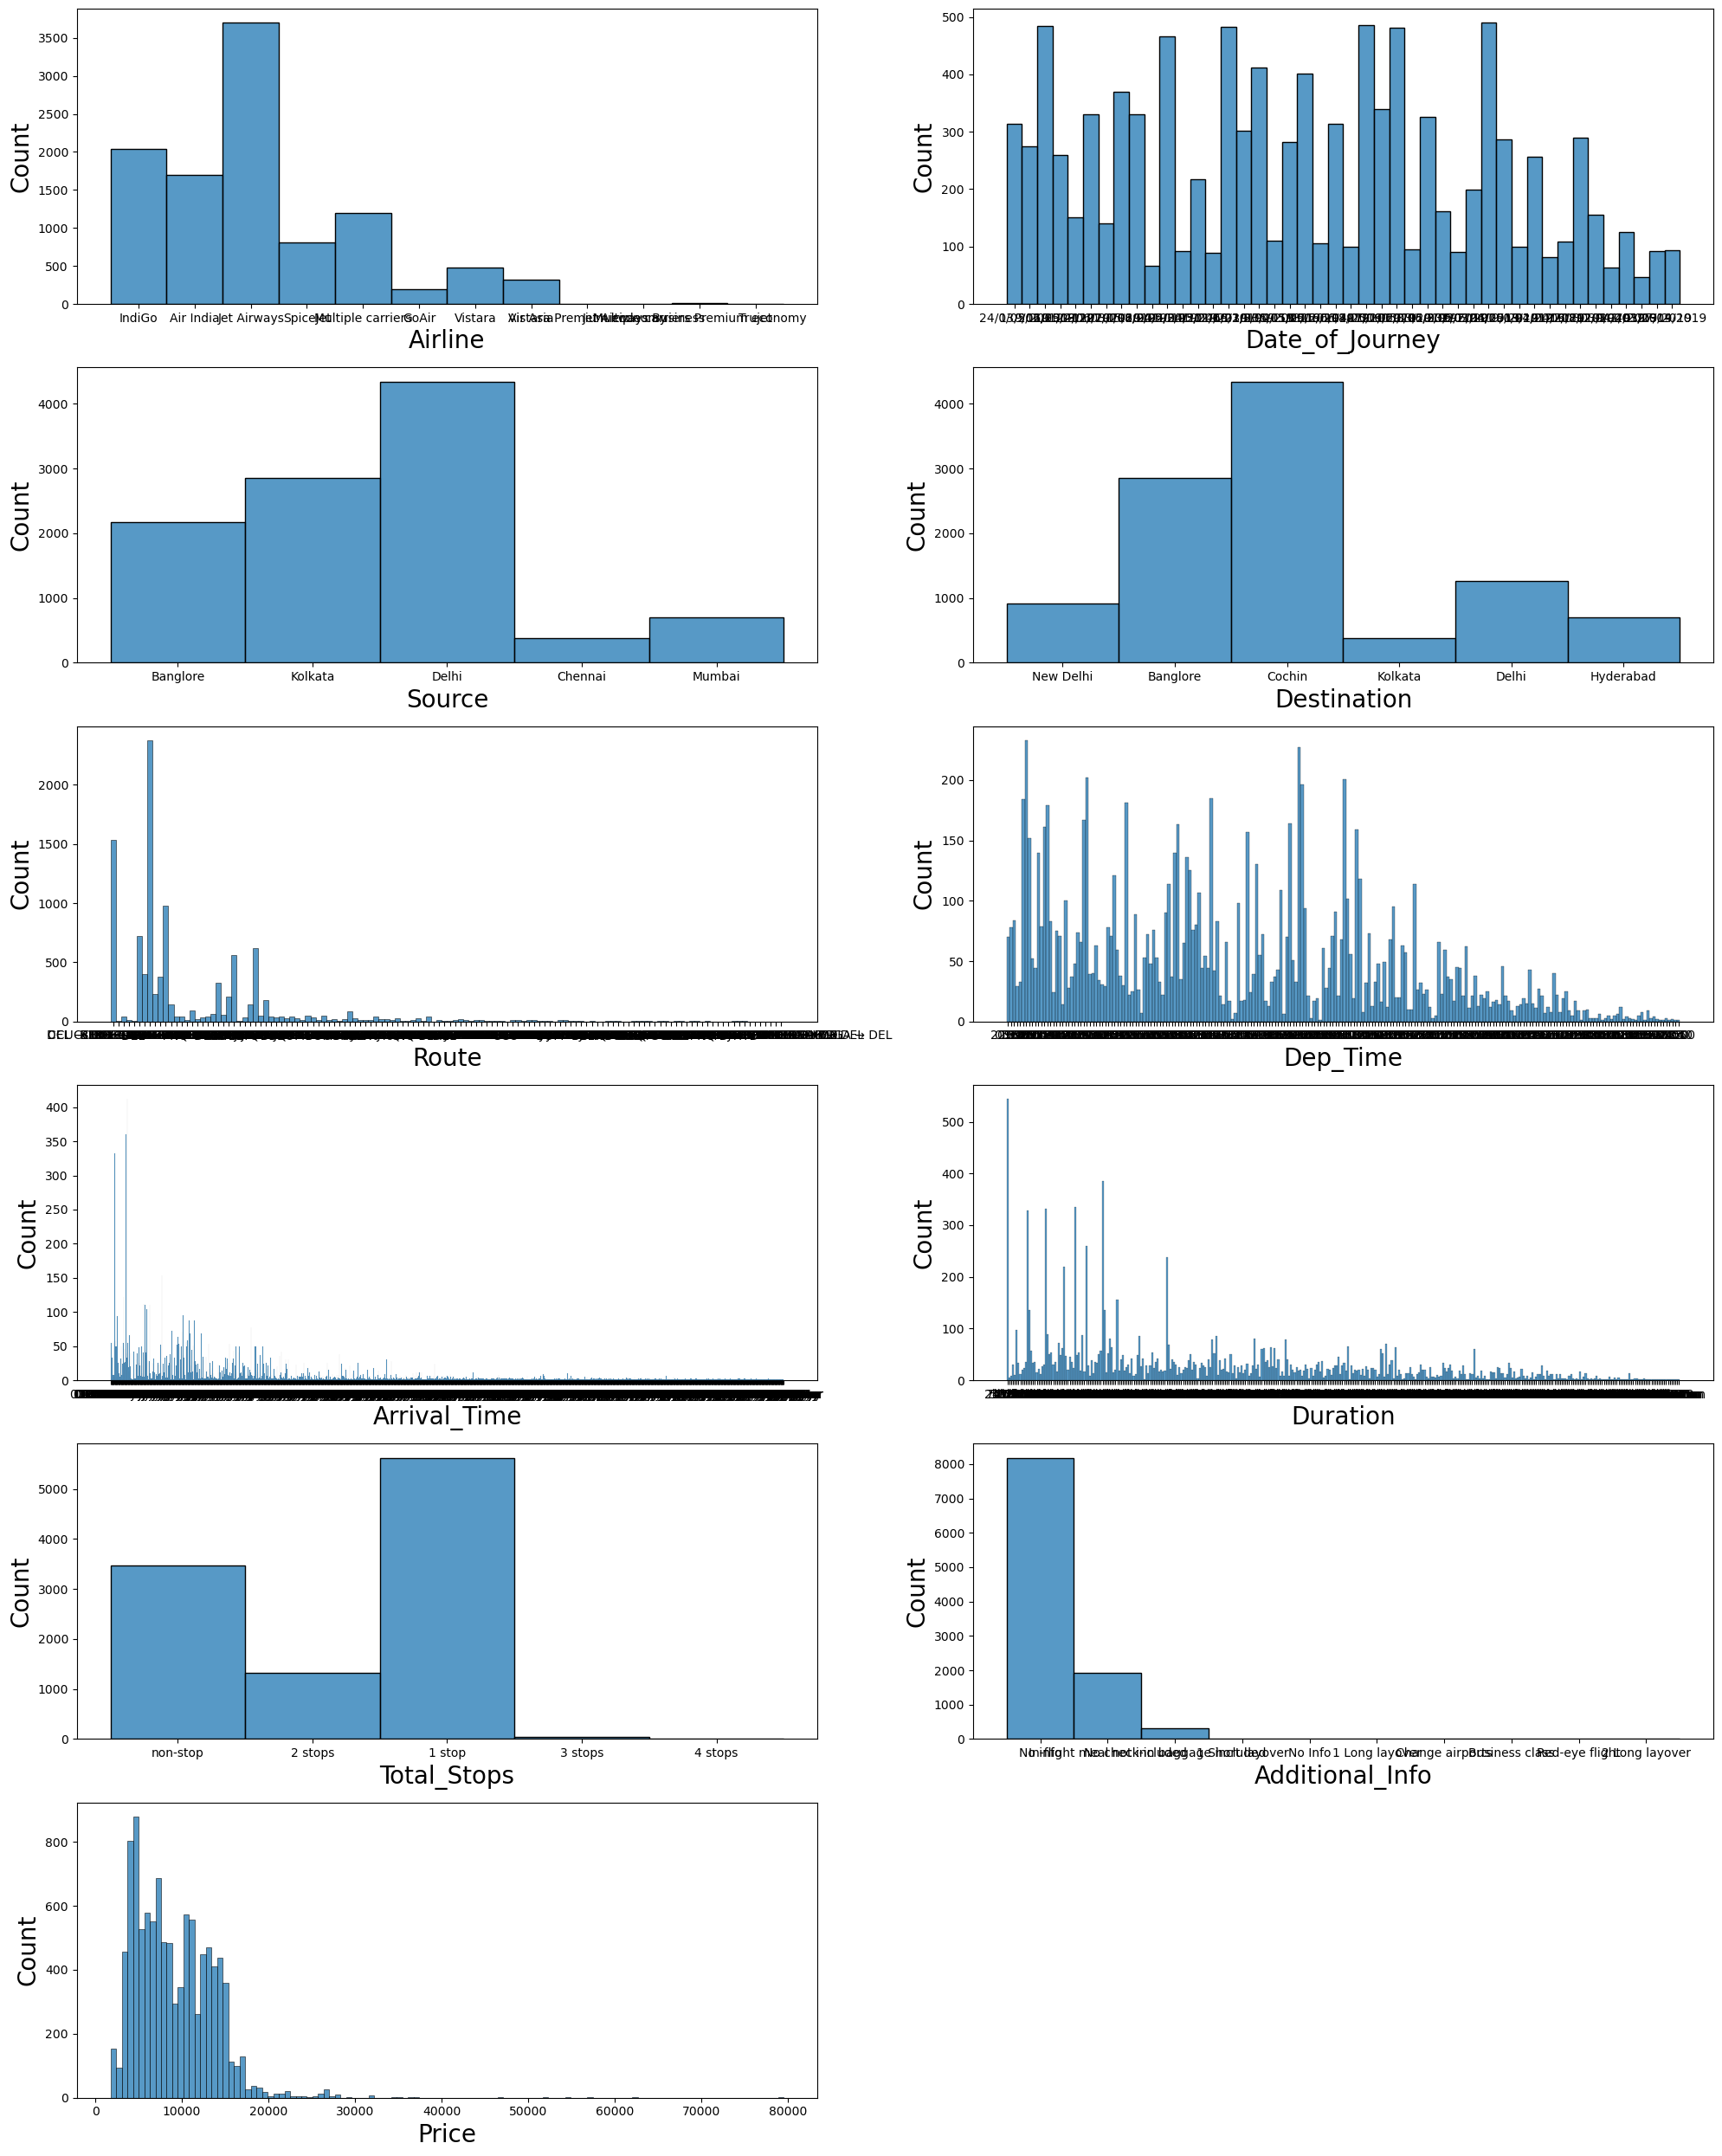

In [21]:
plt.figure(figsize=(20,25), facecolor = 'white')
plotnumber = 1
for column in df:
    if plotnumber<=12:
        ax = plt.subplot(6,2,plotnumber)
        sns.histplot(x = df[column],ax = ax)
        plt.xlabel(column,fontsize=20)
        plt.ylabel('Count', fontsize=20)
    plotnumber+=1
plt.tight_layout()

<Axes: xlabel='Airline', ylabel='count'>

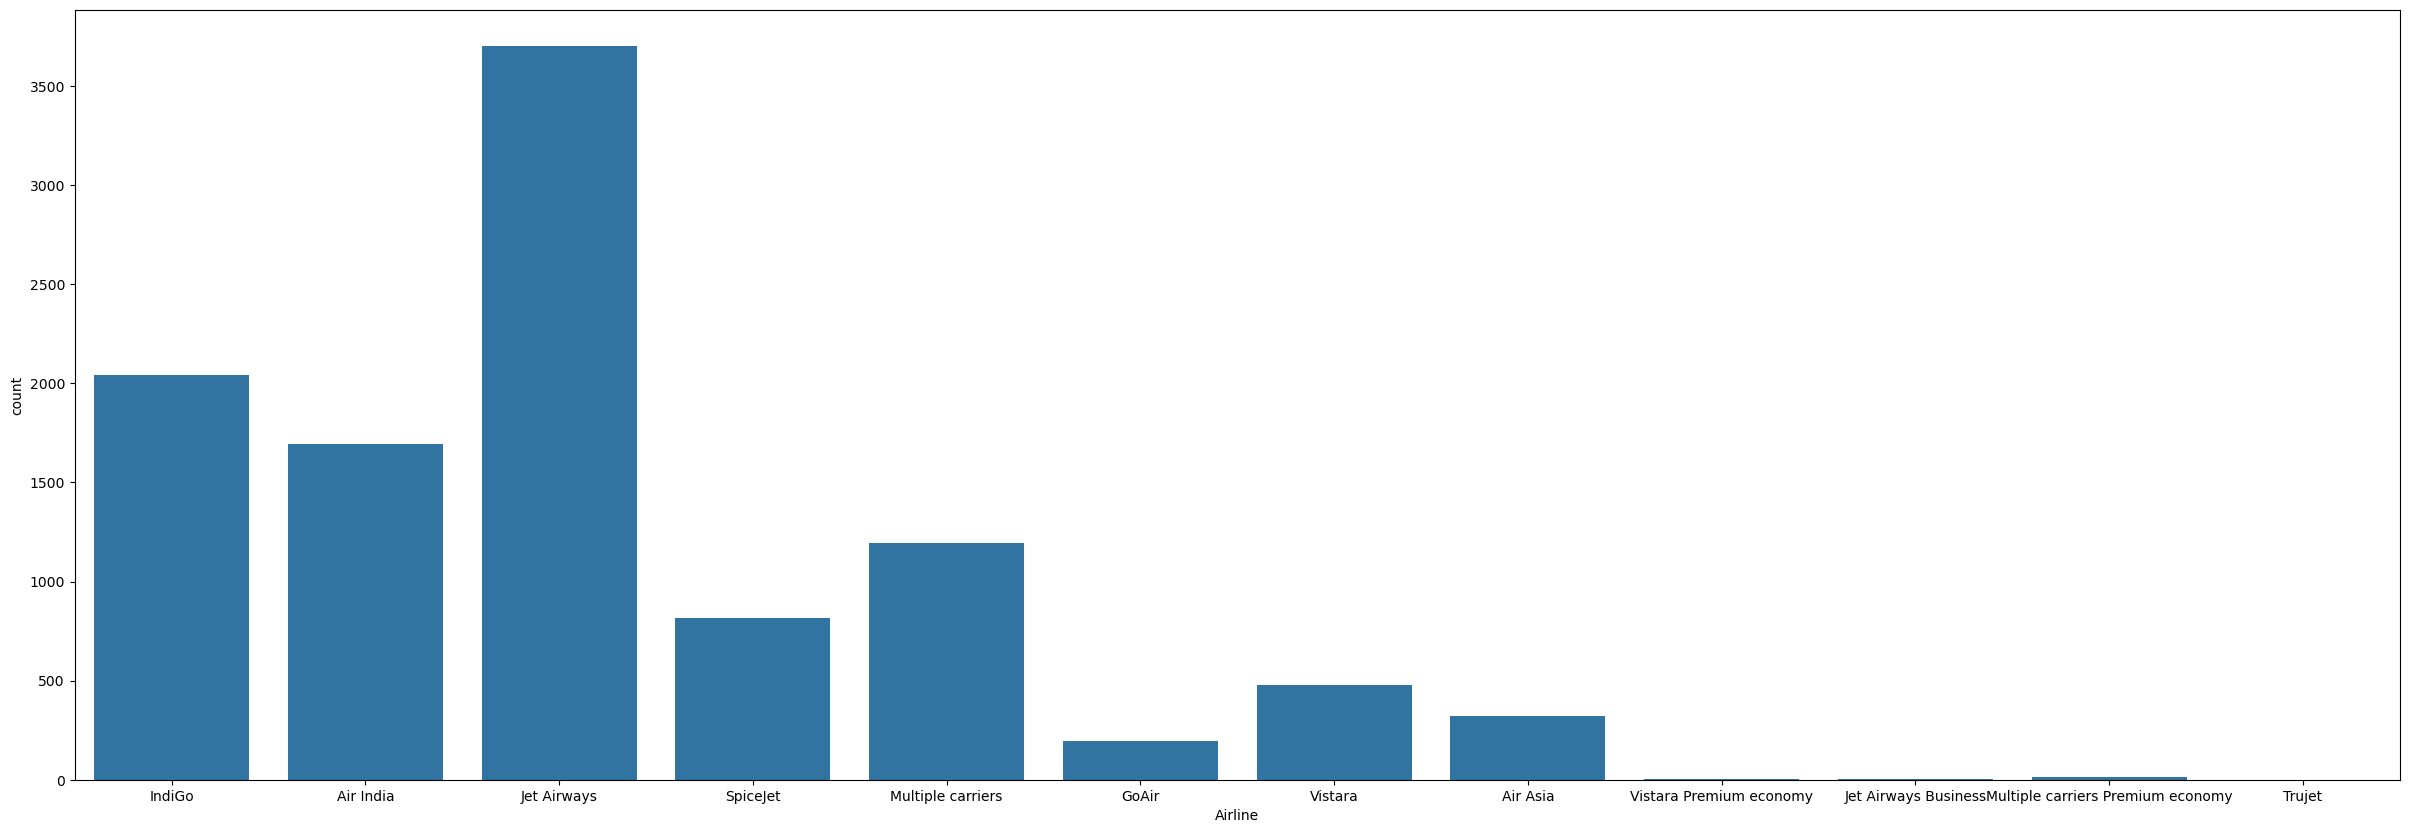

In [22]:
plt.figure(figsize=(30,10))
df['Airline'].value_counts()
sns.countplot(x='Airline', data=df)


In [23]:
# more clear than the plt 
df["Airline"].value_counts()

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1695
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [25]:
# rough work
df["Airline"].value_counts()

Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1695
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [26]:
# droping the non operation airlines
df = df[df["Airline"] != "Jet Airways"]
df = df[df["Airline"] != "Jet Airways Business"]
df = df[df["Airline"] != "GoAir"]
df = df[df["Airline"] != "Trujet"]

In [27]:
df.shape

(6562, 11)

In [28]:
# no useful waste 39 percentage 
(10683-6562)/10683*100

38.5753065618272

In [29]:
# checking for null values in the dataset 
df.isnull().sum()

Airline            0
Date_of_Journey    0
Source             0
Destination        0
Route              0
Dep_Time           0
Arrival_Time       0
Duration           0
Total_Stops        0
Additional_Info    0
Price              0
dtype: int64

In [30]:
df.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [31]:
df.describe()

,Price
count,6562.000000
mean,7625.425937
std,3881.194409
min,1759.000000
25%,4668.000000
50%,6649.000000
75%,9904.750000
max,36983.000000


###  Insights:
 1. The standerad deviation is very high
 2. The lowest price fare is 1759 whereas the highest is 79512 comparing with the mean it shows the variation is very high which incides that the data may have outliears
 3.  Need to change to int (airline,source,destination,(route i am not sure) and total_stops)
 4. Extract (date_of_journey,dep_time,arrival_time,duration)

In [33]:
df.dtypes

Airline            object
Date_of_Journey    object
Source             object
Destination        object
Route              object
Dep_Time           object
Arrival_Time       object
Duration           object
Total_Stops        object
Additional_Info    object
Price               int64
dtype: object

In [34]:
# since more than 70 percentage of data has no info we are droping this column
df["Additional_Info"].value_counts()

Additional_Info
No info                         6128
No check-in baggage included     318
In-flight meal not included       96
1 Long layover                     7
Change airports                    7
No Info                            3
1 Short layover                    1
Red-eye flight                     1
2 Long layover                     1
Name: count, dtype: int64

In [35]:
df.drop(columns=["Additional_Info"],axis=1,inplace=True)

In [36]:
df.head(6)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,7662
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,13302
5,SpiceJet,24/06/2019,Kolkata,Banglore,CCU → BLR,09:00,11:25,2h 25m,non-stop,3873
9,Multiple carriers,27/05/2019,Delhi,Cochin,DEL → BOM → COK,11:25,19:15,7h 50m,1 stop,8625


In [37]:
# ordinal encoding
df.replace({'non-stop':0,'1 stop':1,'2 stops':2,'3 stops':3,'4 stops':4},inplace=True)

# Feature engineering

In [39]:
df["Journey_Day"]=pd.to_datetime(df["Date_of_Journey"],format="%d/%m/%Y").dt.day
df["journey_Month"]=pd.to_datetime(df["Date_of_Journey"],format="%d/%m/%Y").dt.month

In [40]:
df.head(1)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Journey_Day,journey_Month
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,3897,24,3


In [41]:
df["dep_Hours"]=pd.to_datetime(df["Dep_Time"]).dt.hour
df["dep_Minutes"]=pd.to_datetime(df["Dep_Time"]).dt.minute

In [42]:
df['Arrival_Hours'] = pd.to_datetime(df['Arrival_Time']).dt.hour
df['Arrival_Minutes'] = pd.to_datetime(df['Arrival_Time']).dt.minute

In [43]:
# 1. Clean Duration column for timedelta conversion
df["Duration_cleaned"] = df["Duration"].str.replace("h", " hours").str.replace("m", " minutes")

# 2. Convert to timedelta
df["Duration_cleaned"] = pd.to_timedelta(df["Duration_cleaned"])

# 3. Create new columns
df["Duration_Hours"] = df["Duration_cleaned"].dt.components['hours']
df["Duration_Minutes"] = df["Duration_cleaned"].dt.components['minutes']

In [44]:
df.head(2)

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Price,Journey_Day,journey_Month,dep_Hours,dep_Minutes,Arrival_Hours,Arrival_Minutes,Duration_cleaned,Duration_Hours,Duration_Minutes
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,3897,24,3,22,20,1,10,0 days 02:50:00,2,50
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,7662,1,5,5,50,13,15,0 days 07:25:00,7,25


In [45]:
# drop the columns which are now of no use since we have extract the data into new columns
df.drop(columns=["Date_of_Journey","Dep_Time","Arrival_Time","Duration","Duration_cleaned","Route"],axis=1,inplace=True)

In [46]:
df.head(3)

,Airline,Source,Destination,Total_Stops,Price,Journey_Day,journey_Month,dep_Hours,dep_Minutes,Arrival_Hours,Arrival_Minutes,Duration_Hours,Duration_Minutes
0,IndiGo,Banglore,New Delhi,0,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,5,50,13,15,7,25
3,IndiGo,Kolkata,Banglore,1,6218,12,5,18,5,23,30,5,25


In [47]:
# i will decide whether to drop the duration_cleaned column or not after seeing the correlation

In [48]:
df.dtypes

Airline             object
Source              object
Destination         object
Total_Stops          int64
Price                int64
Journey_Day          int32
journey_Month        int32
dep_Hours            int32
dep_Minutes          int32
Arrival_Hours        int32
Arrival_Minutes      int32
Duration_Hours       int64
Duration_Minutes     int64
dtype: object

Text(0.5, 1.0, 'Price Distribution')

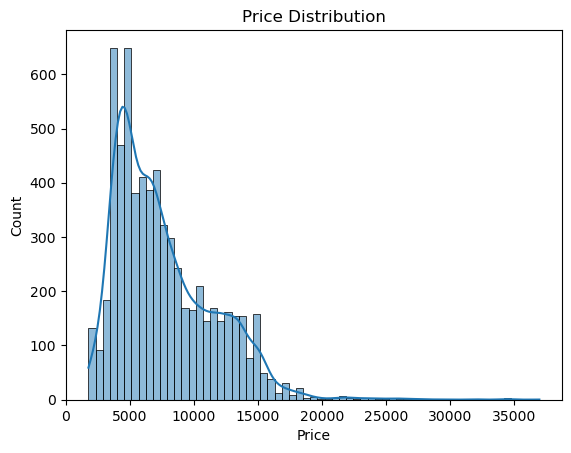

In [49]:
sns.histplot(df["Price"], kde=True)
plt.title("Price Distribution")


In [50]:
df.describe()  

,Total_Stops,Price,Journey_Day,journey_Month,dep_Hours,dep_Minutes,Arrival_Hours,Arrival_Minutes,Duration_Hours,Duration_Minutes
count,6562.000000,6562.000000,6562.000000,6562.000000,6562.000000,6562.000000,6562.000000,6562.000000,6562.000000,6562.000000
mean,0.710607,7625.425937,13.630753,4.660012,11.973179,23.767144,13.446053,25.113532,6.428528,29.206797
std,0.694596,3881.194409,8.556761,1.174494,5.663576,18.717760,7.201811,16.710461,5.598394,16.204128
min,0.000000,1759.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4668.000000,6.000000,3.000000,7.000000,5.000000,8.000000,15.000000,2.000000,15.000000
50%,1.000000,6649.000000,12.000000,5.000000,11.000000,20.000000,15.000000,25.000000,4.000000,30.000000
75%,1.000000,9904.750000,21.000000,6.000000,17.000000,40.000000,19.000000,40.000000,10.000000,45.000000
max,4.000000,36983.000000,27.000000,6.000000,23.000000,55.000000,23.000000,55.000000,23.000000,55.000000


<Axes: xlabel='Price'>

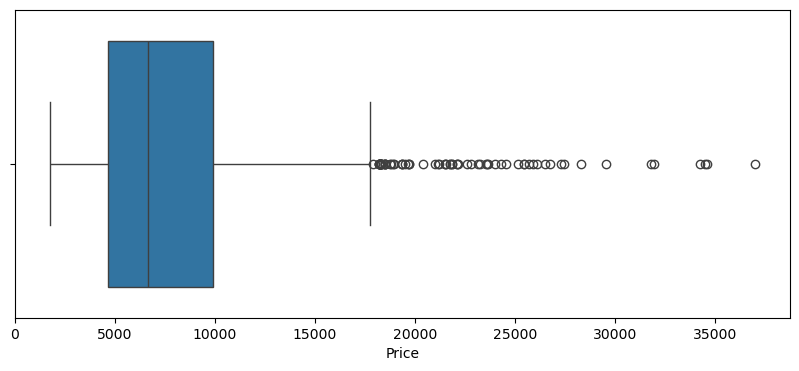

In [51]:
# Boxplot to find outliers
plt.figure(figsize=(10,4))
sns.boxplot(x="Price",data=df)

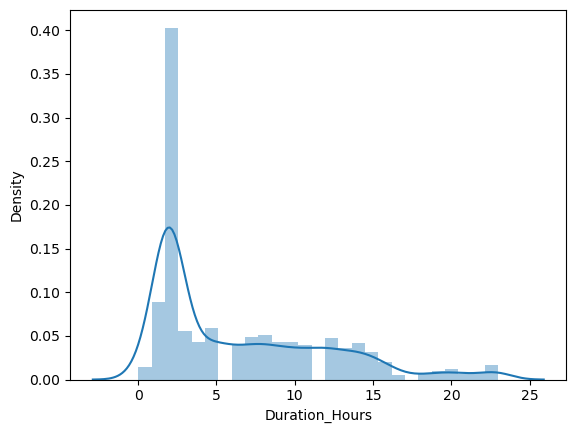

In [52]:
# the tail 
sns.distplot(df["Duration_Hours"])
plt.show()

# Removing outliers from the price column using IQR method 


In [54]:
df.shape

(6562, 13)

In [55]:
df.describe()

,Total_Stops,Price,Journey_Day,journey_Month,dep_Hours,dep_Minutes,Arrival_Hours,Arrival_Minutes,Duration_Hours,Duration_Minutes
count,6562.000000,6562.000000,6562.000000,6562.000000,6562.000000,6562.000000,6562.000000,6562.000000,6562.000000,6562.000000
mean,0.710607,7625.425937,13.630753,4.660012,11.973179,23.767144,13.446053,25.113532,6.428528,29.206797
std,0.694596,3881.194409,8.556761,1.174494,5.663576,18.717760,7.201811,16.710461,5.598394,16.204128
min,0.000000,1759.000000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,4668.000000,6.000000,3.000000,7.000000,5.000000,8.000000,15.000000,2.000000,15.000000
50%,1.000000,6649.000000,12.000000,5.000000,11.000000,20.000000,15.000000,25.000000,4.000000,30.000000
75%,1.000000,9904.750000,21.000000,6.000000,17.000000,40.000000,19.000000,40.000000,10.000000,45.000000
max,4.000000,36983.000000,27.000000,6.000000,23.000000,55.000000,23.000000,55.000000,23.000000,55.000000


In [56]:
q1=df["Price"].quantile(0.25)
q1

4668.0

In [57]:
q3=df["Price"].quantile(0.75)
q3

9904.75

In [58]:
IQR=q1=q3
min_range=q1-(1.5*IQR)
max_range=q3+(1.5*IQR)
min_range,max_range

(-4952.375, 24761.875)

In [59]:
new_df=df[df["Price"]<=max_range]
new_df

,Airline,Source,Destination,Total_Stops,Price,Journey_Day,journey_Month,dep_Hours,dep_Minutes,Arrival_Hours,Arrival_Minutes,Duration_Hours,Duration_Minutes
0,IndiGo,Banglore,New Delhi,0,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,5,50,13,15,7,25
3,IndiGo,Kolkata,Banglore,1,6218,12,5,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,16,50,21,35,4,45
5,SpiceJet,Kolkata,Banglore,0,3873,24,6,9,0,11,25,2,25
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10677,SpiceJet,Banglore,Delhi,0,3257,21,5,5,55,8,35,2,40
10678,Air Asia,Kolkata,Banglore,0,4107,9,4,19,55,22,25,2,30
10679,Air India,Kolkata,Banglore,0,4145,27,4,20,45,23,20,2,35
10681,Vistara,Banglore,New Delhi,0,12648,1,3,11,30,14,10,2,40


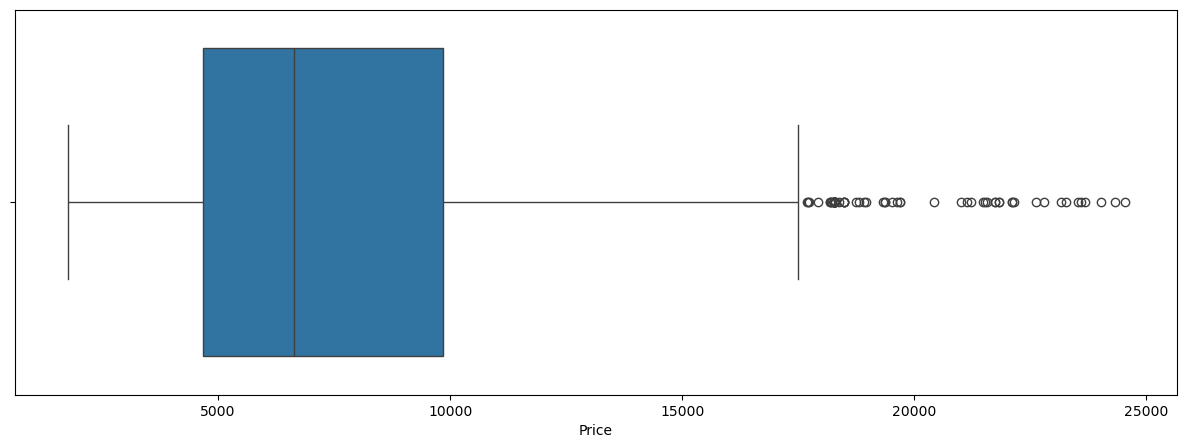

In [60]:
plt.figure(figsize=(15,5))
sns.boxplot(x="Price",data=new_df)
plt.show()

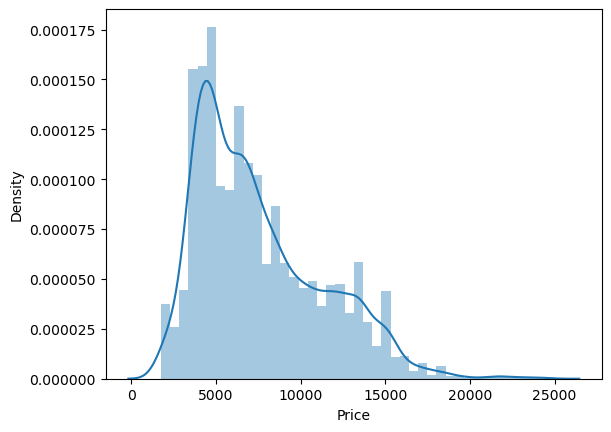

In [61]:
sns.distplot(new_df["Price"])
plt.show()

In [62]:
new_df.head(2)

,Airline,Source,Destination,Total_Stops,Price,Journey_Day,journey_Month,dep_Hours,dep_Minutes,Arrival_Hours,Arrival_Minutes,Duration_Hours,Duration_Minutes
0,IndiGo,Banglore,New Delhi,0,3897,24,3,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,5,50,13,15,7,25


In [63]:
new_df.shape

(6544, 13)

In [64]:
df.shape

(6562, 13)

In [65]:
# number of rows removed after the treating outliers
6562-6544

18

In [66]:
# max price of the flight
df[df["Price"] == df["Price"].max()]


,Airline,Source,Destination,Total_Stops,Price,Journey_Day,journey_Month,dep_Hours,dep_Minutes,Arrival_Hours,Arrival_Minutes,Duration_Hours,Duration_Minutes
396,Multiple carriers,Delhi,Cochin,1,36983,1,3,12,50,19,15,6,25


In [67]:
new_df["Price"].value_counts()

Price
4804     160
4823     131
3943     104
3841      91
3597      86
        ... 
14153      1
8488       1
6315       1
14260      1
12648      1
Name: count, Length: 1466, dtype: int64

In [68]:
df=new_df

# Encoding 

In [70]:
from sklearn.preprocessing import OneHotEncoder,LabelEncoder

In [71]:
df.head(1)

,Airline,Source,Destination,Total_Stops,Price,Journey_Day,journey_Month,dep_Hours,dep_Minutes,Arrival_Hours,Arrival_Minutes,Duration_Hours,Duration_Minutes
0,IndiGo,Banglore,New Delhi,0,3897,24,3,22,20,1,10,2,50


In [72]:
df.dtypes

Airline             object
Source              object
Destination         object
Total_Stops          int64
Price                int64
Journey_Day          int32
journey_Month        int32
dep_Hours            int32
dep_Minutes          int32
Arrival_Hours        int32
Arrival_Minutes      int32
Duration_Hours       int64
Duration_Minutes     int64
dtype: object

In [73]:
# Performing OHE on Airline column as it is nominal data
# Using drop_first to avoid multicolinearity

Airline=df[['Airline']]
Airline=pd.get_dummies(Airline, dtype=int,drop_first=True)
Airline.head()

,Airline_Air India,Airline_IndiGo,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Vistara,Airline_Vistara Premium economy
0,0,1,0,0,0,0,0
1,1,0,0,0,0,0,0
3,0,1,0,0,0,0,0
4,0,1,0,0,0,0,0
5,0,0,0,0,1,0,0


In [74]:
Source=df[["Source"]]
Source=pd.get_dummies(Source,dtype=int,drop_first=True)
Source.head(2)

,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai
0,0,0,0,0
1,0,0,1,0


In [75]:
Destination=df[["Destination"]]
Destination=pd.get_dummies(Destination,dtype=int,drop_first=True)
Destination

,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,0,0,0,1
1,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,1
5,0,0,0,0,0
...,...,...,...,...,...
10677,0,1,0,0,0
10678,0,0,0,0,0
10679,0,0,0,0,0
10681,0,0,0,0,1


In [76]:
df=pd.concat([df,Airline,Source,Destination],axis=1)
df.drop(['Airline','Source','Destination'],axis=1,inplace=True)
df.head()

,Total_Stops,Price,Journey_Day,journey_Month,dep_Hours,dep_Minutes,Arrival_Hours,Arrival_Minutes,Duration_Hours,Duration_Minutes,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,22,20,1,10,2,50,...,0,0,0,0,0,0,0,0,0,1
1,2,7662,1,5,5,50,13,15,7,25,...,0,0,0,1,0,0,0,0,0,0
3,1,6218,12,5,18,5,23,30,5,25,...,0,0,0,1,0,0,0,0,0,0
4,1,13302,1,3,16,50,21,35,4,45,...,0,0,0,0,0,0,0,0,0,1
5,0,3873,24,6,9,0,11,25,2,25,...,0,0,0,1,0,0,0,0,0,0


In [77]:
df.dtypes

Total_Stops                                  int64
Price                                        int64
Journey_Day                                  int32
journey_Month                                int32
dep_Hours                                    int32
dep_Minutes                                  int32
Arrival_Hours                                int32
Arrival_Minutes                              int32
Duration_Hours                               int64
Duration_Minutes                             int64
Airline_Air India                            int32
Airline_IndiGo                               int32
Airline_Multiple carriers                    int32
Airline_Multiple carriers Premium economy    int32
Airline_SpiceJet                             int32
Airline_Vistara                              int32
Airline_Vistara Premium economy              int32
Source_Chennai                               int32
Source_Delhi                                 int32
Source_Kolkata                 

In [78]:
df.head(2)

,Total_Stops,Price,Journey_Day,journey_Month,dep_Hours,dep_Minutes,Arrival_Hours,Arrival_Minutes,Duration_Hours,Duration_Minutes,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,22,20,1,10,2,50,...,0,0,0,0,0,0,0,0,0,1
1,2,7662,1,5,5,50,13,15,7,25,...,0,0,0,1,0,0,0,0,0,0


In [79]:
pd.set_option('display.max_columns', None)
print(df.columns)

Index(['Total_Stops', 'Price', 'Journey_Day', 'journey_Month', 'dep_Hours',
       'dep_Minutes', 'Arrival_Hours', 'Arrival_Minutes', 'Duration_Hours',
       'Duration_Minutes', 'Airline_Air India', 'Airline_IndiGo',
       'Airline_Multiple carriers',
       'Airline_Multiple carriers Premium economy', 'Airline_SpiceJet',
       'Airline_Vistara', 'Airline_Vistara Premium economy', 'Source_Chennai',
       'Source_Delhi', 'Source_Kolkata', 'Source_Mumbai', 'Destination_Cochin',
       'Destination_Delhi', 'Destination_Hyderabad', 'Destination_Kolkata',
       'Destination_New Delhi'],
      dtype='object')


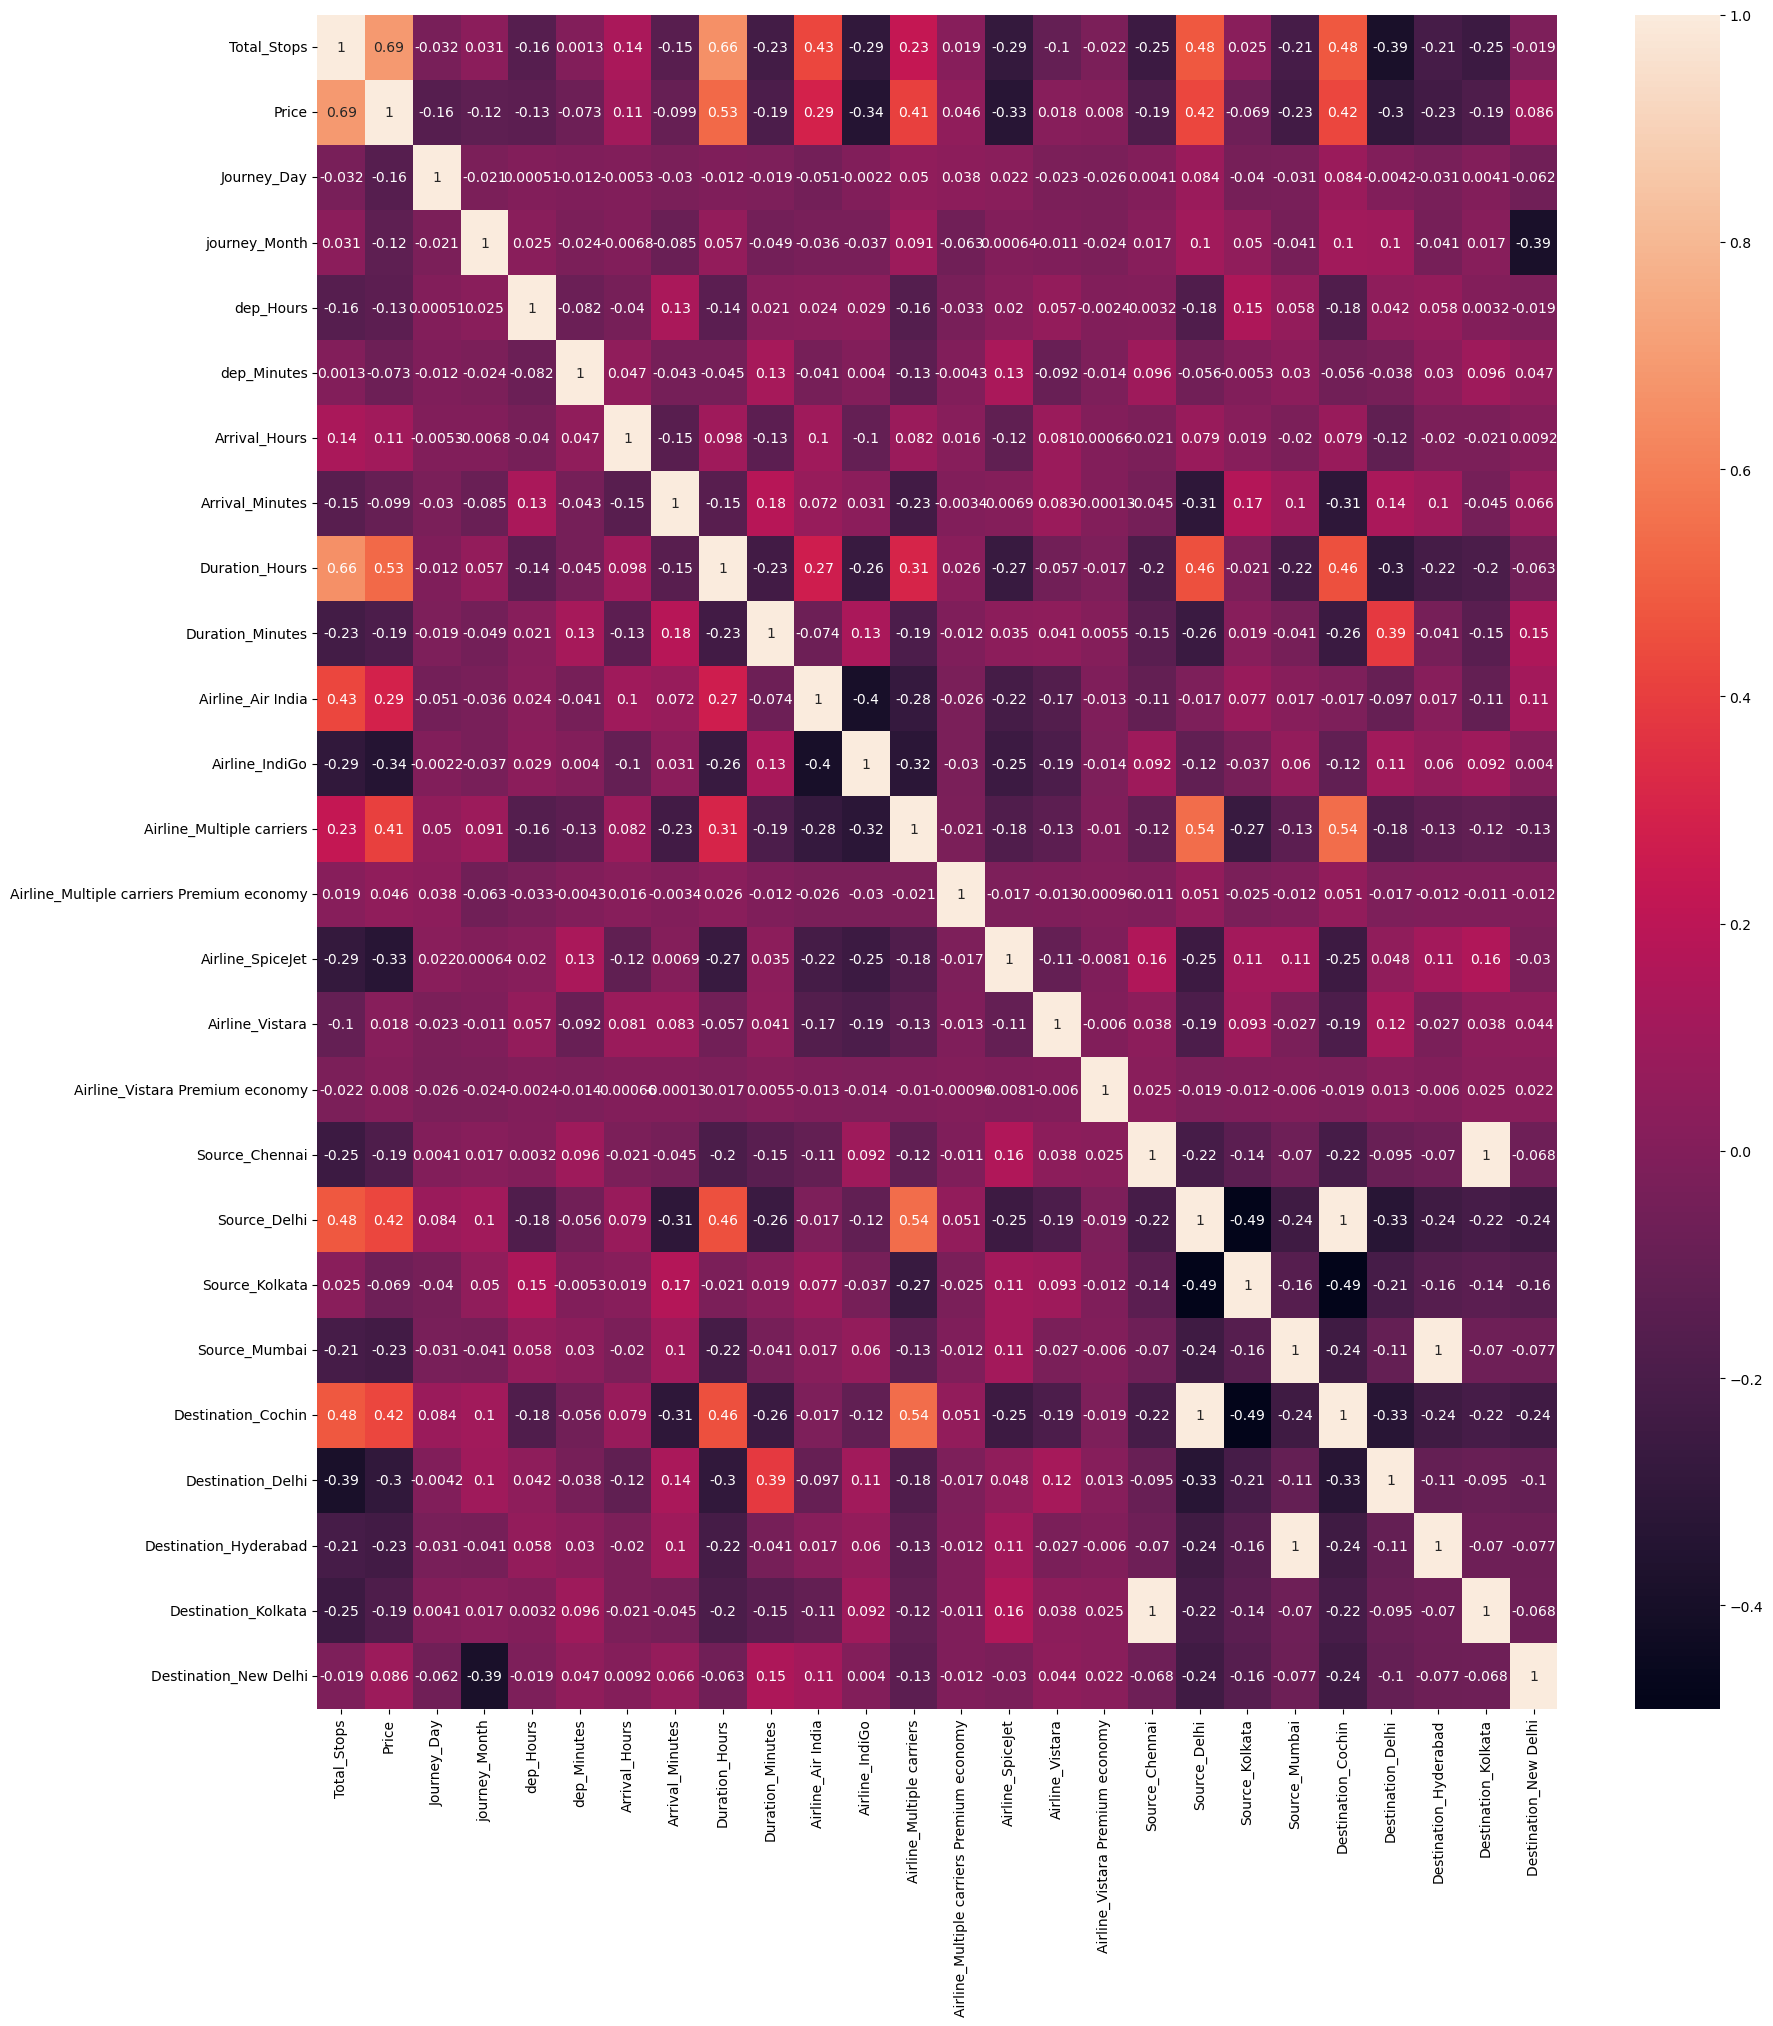

In [170]:
plt.figure(figsize=(20,22))
sns.heatmap(data=df.corr(),annot=True)
plt.show()

In [80]:
# defining features and target
x = df.drop("Price", axis=1)
y = df["Price"]

In [81]:
x.head(2)

,Total_Stops,Journey_Day,journey_Month,dep_Hours,dep_Minutes,Arrival_Hours,Arrival_Minutes,Duration_Hours,Duration_Minutes,Airline_Air India,Airline_IndiGo,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,24,3,22,20,1,10,2,50,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1
1,2,1,5,5,50,13,15,7,25,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0


In [82]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [83]:
from sklearn.preprocessing import StandardScaler

# If using linear model:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [84]:
# Linear model with scaling
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# Predict on test data
y_pred = lr.predict(x_test_scaled)

# Evaluate the model
print(" Linear Regression Evaluation")
print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", np.sqrt(mean_squared_error(y_test, y_pred))) 


 Linear Regression Evaluation
R² Score : 0.6495162810739129
MAE      : 1581.2553385955764
RMSE     : 2199.9597764290666


In [85]:
# linear model
lr.score(x_train_scaled,y_train)*100,lr.score(x_test_scaled,y_test)*100

(64.50034901234041, 64.95162810739129)

In [86]:
x_train.head(2)

,Total_Stops,Journey_Day,journey_Month,dep_Hours,dep_Minutes,Arrival_Hours,Arrival_Minutes,Duration_Hours,Duration_Minutes,Airline_Air India,Airline_IndiGo,Airline_Multiple carriers,Airline_Multiple carriers Premium economy,Airline_SpiceJet,Airline_Vistara,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
2773,0,3,3,5,50,8,40,2,50,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
877,1,27,6,8,45,13,15,4,30,0,0,0,0,1,0,0,0,1,0,0,1,0,0,0,0


## DecisionTreeRegressor

In [103]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

dt = DecisionTreeRegressor(   # have used the best parameters there which we got from randomizedsearchCV
    max_depth=12,
    max_features=None,
    min_samples_leaf=3,
    min_samples_split=13,
    random_state=42
)

dt.fit(x_train, y_train)

DecisionTreeRegressor(max_depth=12, min_samples_leaf=3, min_samples_split=13,
                      random_state=42)

In [105]:
param_dist = {
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 15),
    'min_samples_leaf': randint(1, 10),
    'max_features': ['auto', 'sqrt', 'log2', None]
}


In [107]:
dt = DecisionTreeRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=50,               # try 50 random combinations
    cv=3,                    # 3-fold cross-validation
    scoring='r2',
    verbose=1,
    n_jobs=-1,
    random_state=42
)

random_search.fit(x_train, y_train)
print("Best Parameters:", random_search.best_params_)
print("Best Cross-Validation R² Score:", random_search.best_score_)


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'max_depth': 12, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 13}
Best Cross-Validation R² Score: 0.8044696247368451


In [109]:
best_dt = random_search.best_estimator_
y_pred = best_dt.predict(x_test)

print("Test R² Score :", r2_score(y_test, y_pred))
print("MAE           :", mean_absolute_error(y_test, y_pred))
print("RMSE          :", mean_squared_error(y_test, y_pred, squared=False))


Test R² Score : 0.8095302952240286
MAE           : 933.5578106902753
RMSE          : 1621.7868342221657


## RandomForestRegressor

In [151]:
# Tree model without scaling
from sklearn.ensemble import RandomForestRegressor
rf = RandomForestRegressor(max_depth= 28, max_features="log2", min_samples_leaf=1, min_samples_split= 7, n_estimators= 379)
rf.fit(x_train, y_train)
train_score = rf.score(x_train, y_train) * 100
test_score = rf.score(x_test, y_test) * 100
train_score,test_score

(92.04195486258784, 84.12942934361416)

In [153]:
param_dist = {
    'n_estimators': randint(100, 500),           # number of trees
    'max_depth': randint(5, 30),                 # max depth of tree
    'min_samples_split': randint(2, 15),         # min samples to split
    'min_samples_leaf': randint(1, 10),          # min samples at leaf
    'max_features': ['auto', 'sqrt', 'log2']     # number of features considered
}

In [155]:
rf = RandomForestRegressor(random_state=42)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,              # number of parameter combinations to try
    scoring='r2',
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

In [157]:
random_search.fit(x_train, y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV R² Score:", random_search.best_score_)

# Evaluate on test data
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(x_test)

print("Test R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'max_depth': 28, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 7, 'n_estimators': 379}
Best CV R² Score: 0.826956737376589
Test R² Score: 0.8411819379202959
MAE: 900.0249740105447
RMSE: 1480.9171492098744


## XGBRegressor

In [130]:
from xgboost import XGBRegressor
xgb = XGBRegressor(colsample_bytree= 0.7, learning_rate= 0.1, max_depth= 7, n_estimators= 200, subsample= 1,random_state=42)
xgb.fit(x_train, y_train)

y_pred = xgb.predict(x_test)

from sklearn.metrics import r2_score
print("XGBoost Test R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


XGBoost Test R² Score: 0.8912478089332581
MAE: 693.7730830391461
RMSE: 1225.461872307416


In [132]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 1],
    'colsample_bytree': [0.7, 1]
}


In [163]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_grid=param_grid,
    scoring='r2',
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(x_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best Score on Training Set:", grid.best_score_)

# Evaluate on test data
best_xgb = grid.best_estimator_
y_pred = best_xgb.predict(x_test)
print("XGBoost Test R² Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))


Fitting 3 folds for each of 72 candidates, totalling 216 fits
Best Parameters: {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1}
Best Score on Training Set: 0.8797533909479777
XGBoost Test R² Score: 0.8912478089332581
MAE: 693.7730830391461
RMSE: 1225.461872307416


## AdaBoostRegressor

In [140]:
from sklearn.ensemble import AdaBoostRegressor

# Define weak learner
base_model = DecisionTreeRegressor(max_depth=3)

# AdaBoost with updated parameter name
ada = AdaBoostRegressor(
    estimator=base_model,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

ada.fit(x_train, y_train)



AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=3),
                  learning_rate=0.1, n_estimators=100, random_state=42)

In [141]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

y_pred = ada.predict(x_test)

print("R² Score :", r2_score(y_test, y_pred))
print("MAE      :", mean_absolute_error(y_test, y_pred))
print("RMSE     :", mean_squared_error(y_test, y_pred, squared=False))


R² Score : 0.6588329726375866
MAE      : 1700.878564602444
RMSE     : 2170.5227483385593


## The scores of each models from lowest to highest 

1.Linear Regression Evaluation
R² Score : 0.6495162810739129
MAE      : 1581.2553385955764
RMSE     : 2199.9597764290666

2.AdaBoostRegressor
R² Score : 0.6588329726375866
MAE      : 1700.878564602444
RMSE     : 2170.5227483385593

3.DTRegressor
Test R² Score : 0.8095302952240286
MAE           : 933.5578106902753
RMSE          : 1621.7868342221657

4.RFRegressor
Test R² Score: 0.8411819379202959
MAE: 900.0249740105447
RMSE: 1480.9171492098744

5.XGBoost
XGBoost Test R² Score: 0.8912478089332581
MAE: 693.7730830391461
RMSE: 1225.461872307416